# Tema : Modelos ARIMA
![](src/img/logo_utb.png){width=40%} 
![](src/img/logo_etd.png){width=40%}
- **Profesor:**
- **Fernando Salcedo Mejía, Eco Msc.**
- Programa de Ciencias de Datos | Escuela de transformación digital.
- 2026-1

## Ejercicio 1. Pronostico del PIB de Colombia.

- Usando los datos del Banco Mundial, estime un modelo ARIMA válido acorde a la teoría entre 1960-2024. Finalmente, realice el pronostico del PIB de Colombia para los próximos 5 años.



In [2]:
# Librerias necesarias

# Datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wbgapi as wb

# Modelos de tiempo
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

# Estadisticos
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.metrics import r2_score


# Descargar los datos del Banco Mundial

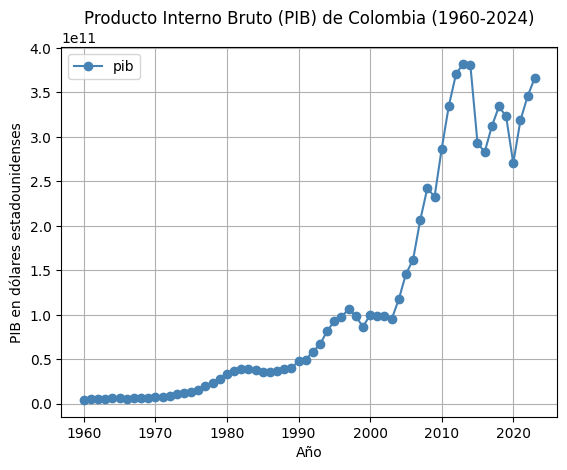

In [3]:
data = wb.data.DataFrame(series='NY.GDP.MKTP.CD', economy='COL', time=range(1960, 2024), columns='series').reset_index()
data.columns = ['year', 'pib']
data['year'] = data['year'].str.replace('YR', '').astype(int)
data.index = data.year

data.plot(x='year', y='pib', kind='line', marker='o', color='steelblue')
plt.title('Producto Interno Bruto (PIB) de Colombia (1960-2024)')
plt.xlabel('Año')
plt.ylabel('PIB en dólares estadounidenses')
plt.grid()
plt.show()

## Verificar estacionaridad de la serie

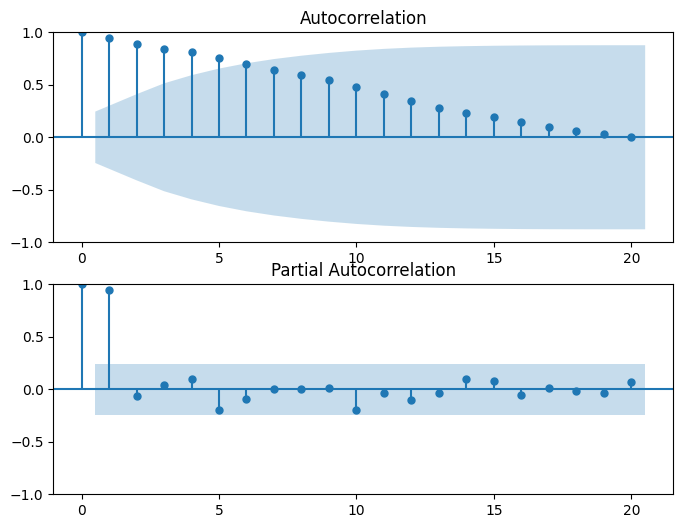

In [4]:
# Graficar la funcion de ACF y PACF
fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(data.pib, lags=20, ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(data.pib, lags=20, ax=ax2)

In [5]:
def test_autocorrelacion(datos, n_lags=20):
    # Ljung-Box (Prueba global)
    lb_test        = acorr_ljungbox(datos, lags=n_lags, return_df=True)
    min_p_value    = lb_test['lb_pvalue'].min()
    lb_stat        = lb_test.loc[lb_test['lb_pvalue'] == min_p_value, 'lb_stat'].iloc[0]

    # Durbin-Watson (Autocorrelación de primer orden)
    dw_stat = durbin_watson(datos)

    # Tabla de resultados
    tab_test = pd.DataFrame({
        'Test'        : ["Durbin-Watson", f"Ljung-Box (hasta lag {n_lags})"],
        'Estadístico' : [round(dw_stat, 4), round(lb_stat, 4)],
        'P-valor'     : [None, round(min_p_value, 4)]
    })

    # Conclusiones
    dw_conclu = (
        "Sin autocorrelación" if 1.5 < dw_stat < 2.5 else
        "Autocorrelación positiva" if dw_stat < 1.5 else
        "Autocorrelación negativa"
    )
    lb_conclu = "Sin autocorrelación" if min_p_value > 0.05 else "Autocorrelación detectada"
    tab_test['Conclusión'] = [dw_conclu, lb_conclu]

    print("=" * 65)
    print("PRUEBA DE LJUNG-BOX Y DURBIN-WATSON")
    print("=" * 65)
    print(tab_test.to_string(index=False))
    print("=" * 65)

test_autocorrelacion(data.pib, n_lags=20)

PRUEBA DE LJUNG-BOX Y DURBIN-WATSON
                    Test  Estadístico  P-valor                Conclusión
           Durbin-Watson       0.0152      NaN  Autocorrelación positiva
Ljung-Box (hasta lag 20)     418.2162      0.0 Autocorrelación detectada


In [6]:
def test_estacionariedad(datos, maxlag=20):
    # Augmented Dickey-Fuller
    adf_stat, adf_pvalue, adf_lags, *_ = adfuller(datos, maxlag=maxlag)

    # KPSS
    kpss_stat, kpss_pvalue, kpss_lags, _ = kpss(datos, regression='c', nlags='auto')

    # Tabla de resultados
    tab_test = pd.DataFrame({
        'Test'        : ["ADF", "KPSS"],
        'Estadístico' : [round(adf_stat,  4), round(kpss_stat,  4)],
        'P-valor'     : [round(adf_pvalue, 4), round(kpss_pvalue, 4)]
    })

    # Conclusiones
    adf_conclu  = "Estacionaria"     if adf_pvalue  < 0.05 else "No estacionaria"
    kpss_conclu = "No estacionaria"  if kpss_pvalue < 0.05 else "Estacionaria"
    tab_test['Conclusión'] = [adf_conclu, kpss_conclu]

    print("=" * 65)
    print("PRUEBA DE ESTACIONARIEDAD")
    print("=" * 65)
    print(tab_test.to_string(index=False))
    print("=" * 65)


test_estacionariedad(data.pib, maxlag=20)

PRUEBA DE ESTACIONARIEDAD
Test  Estadístico  P-valor      Conclusión
 ADF       1.6037   0.9979 No estacionaria
KPSS       0.9984   0.0100 No estacionaria


C:\Users\fsalcedo\AppData\Local\Temp\ipykernel_19408\163315786.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pvalue, kpss_lags, _ = kpss(datos, regression='c', nlags='auto')


## Integración de la serie para estacionaridad

- Es usual transformar la series económicas en términos de crecimiento porcentual aplicando logaritmos y posterior tomar su primera diferencia que es equivalente a incremento porcentual.
- Como vimos en la transformación de Box-Cox (λ=0), el logaritmo ayuda a linealizar funciones exponenciales y varianza creciente.

$$
\Delta \log{y_t} = \log{y_t} - \log{y_{t-1}} = \log{\frac{y_t}{y_{t-1}}} \sim \%\Delta y_t
$$

In [7]:
# Primera diferencia de la serie integrada de orden 1
# Tomamos el logaritmo y la primera diferencia. Esto transforma la serie en tasas de crecimiento
pib_crecimiento = np.log(data["pib"]).diff().dropna()

PRUEBA DE ESTACIONARIEDAD
Test  Estadístico  P-valor      Conclusión
 ADF      -0.7822   0.8243 No estacionaria
KPSS       0.1462   0.1000    Estacionaria


C:\Users\fsalcedo\AppData\Local\Temp\ipykernel_19408\163315786.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, kpss_lags, _ = kpss(datos, regression='c', nlags='auto')


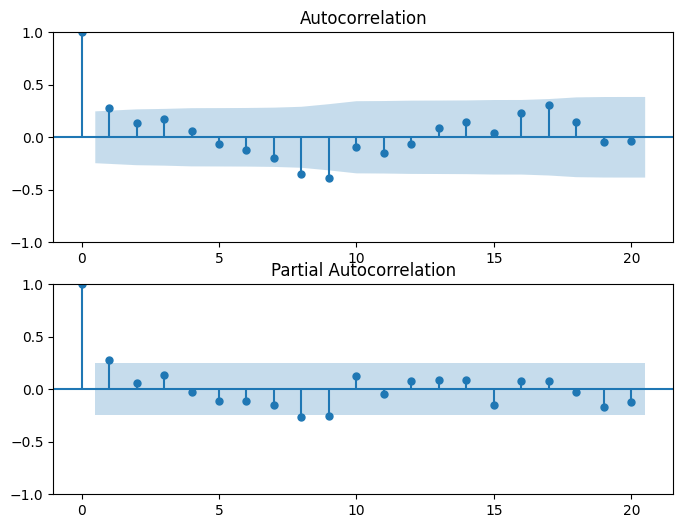

In [8]:
# Graficar la funcion de ACF y PACF
fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(pib_crecimiento, lags=20, ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(pib_crecimiento, lags=20, ax=ax2)

# Test estacionariedad
test_estacionariedad(pib_crecimiento, maxlag=20)

## Estimación modelos ARIMA

In [9]:
# ARIMA(1, 1, 0)
m_arima110 = ARIMA(pib_crecimiento, order = (1, 0, 0)).fit()
print(m_arima110.summary())

# guardar
modelos = {}
modelos["ARIMA(1, 1, 0)"] = m_arima110

                               SARIMAX Results                                
Dep. Variable:                    pib   No. Observations:                   63
Model:                 ARIMA(1, 0, 0)   Log Likelihood                  55.505
Date:                Wed, 25 Feb 2026   AIC                           -105.010
Time:                        10:18:42   BIC                            -98.581
Sample:                             0   HQIC                          -102.481
                                 - 63                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0718      0.020      3.657      0.000       0.033       0.110
ar.L1          0.2795      0.128      2.187      0.029       0.029       0.530
sigma2         0.0100      0.002      5.751      0.0

c:\Users\fsalcedo\AppData\Local\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\fsalcedo\AppData\Local\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\fsalcedo\AppData\Local\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [10]:
# ARIMA(0, 1, 1)
m_arima011 = ARIMA(pib_crecimiento, order = (0, 0, 1)).fit()
print(m_arima011.summary())

# guardar
modelos["ARIMA(0, 1, 1)"] = m_arima011

                               SARIMAX Results                                
Dep. Variable:                    pib   No. Observations:                   63
Model:                 ARIMA(0, 0, 1)   Log Likelihood                  55.215
Date:                Wed, 25 Feb 2026   AIC                           -104.430
Time:                        10:18:42   BIC                            -98.000
Sample:                             0   HQIC                          -101.901
                                 - 63                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0717      0.018      4.070      0.000       0.037       0.106
ma.L1          0.2578      0.131      1.972      0.049       0.002       0.514
sigma2         0.0101      0.002      5.765      0.0

c:\Users\fsalcedo\AppData\Local\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\fsalcedo\AppData\Local\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\fsalcedo\AppData\Local\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [11]:
# ARIMA(1, 1, 1)
m_arima111 = ARIMA(pib_crecimiento, order = (1, 0, 1)).fit()
print(m_arima111.summary())

# guardar
modelos["ARIMA(1, 1, 1)"] = m_arima111

                               SARIMAX Results                                
Dep. Variable:                    pib   No. Observations:                   63
Model:                 ARIMA(1, 0, 1)   Log Likelihood                  55.756
Date:                Wed, 25 Feb 2026   AIC                           -103.512
Time:                        10:18:42   BIC                            -94.939
Sample:                             0   HQIC                          -100.140
                                 - 63                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0719      0.023      3.130      0.002       0.027       0.117
ar.L1          0.5701      0.413      1.379      0.168      -0.240       1.380
ma.L1         -0.3204      0.469     -0.683      0.4

c:\Users\fsalcedo\AppData\Local\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\fsalcedo\AppData\Local\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\fsalcedo\AppData\Local\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [12]:
def comparar_modelos_arima(modelos: dict) -> pd.DataFrame:
    df_modelos = (
        pd.DataFrame({
            "Modelo"  : list(modelos),
            "AIC"     : [m.aic       for m in modelos.values()],
            "AICc"    : [m.aicc      for m in modelos.values()],
            "BIC"     : [m.bic       for m in modelos.values()],
            "Log-Lik" : [m.llf       for m in modelos.values()],
            "MSE"     : [m.mse       for m in modelos.values()],
            "RMSE"    : [m.mse**0.5  for m in modelos.values()],
            "MAE"     : [m.mae       for m in modelos.values()],
            "Params"  : [m.df_model  for m in modelos.values()],
            "Obs"     : [m.nobs      for m in modelos.values()],
        })
        .sort_values("AICc")
        .assign(Ranking=lambda df: range(1, len(df) + 1))
        .set_index("Ranking")
    )

    mejor      = df_modelos.iloc[0]["Modelo"]
    mejor_aicc = df_modelos.iloc[0]["AICc"]

    print("=" * 85)
    print("COMPARACIÓN DE MODELOS ARIMA")
    print("=" * 85)
    print(df_modelos.to_string())
    print("-" * 85)
    print(f"  Mejor modelo (menor AICc): {mejor}  →  AICc: {mejor_aicc}")
    print("=" * 85)

comparar_modelos_arima(modelos)

COMPARACIÓN DE MODELOS ARIMA
                 Modelo         AIC        AICc        BIC    Log-Lik       MSE      RMSE       MAE  Params  Obs
Ranking                                                                                                         
1        ARIMA(1, 1, 0) -105.010140 -104.603360 -98.580736  55.505070  0.010042  0.100211  0.078546       3   63
2        ARIMA(0, 1, 1) -104.429871 -104.023091 -98.000467  55.214935  0.010137  0.100681  0.078878       3   63
3        ARIMA(1, 1, 1) -103.511512 -102.821857 -94.938973  55.755756  0.009960  0.099802  0.078475       4   63
-------------------------------------------------------------------------------------
  Mejor modelo (menor AICc): ARIMA(1, 1, 0)  →  AICc: -104.60336018256797


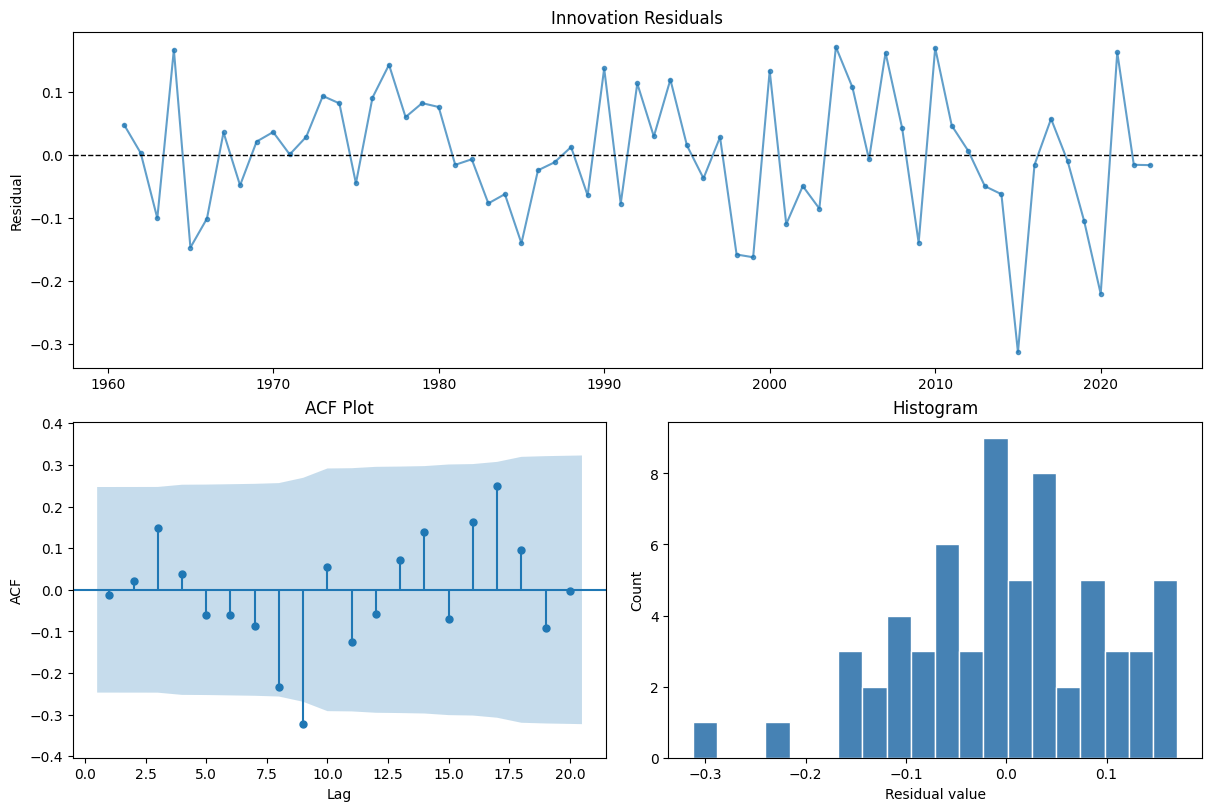

PRUEBA DE LJUNG-BOX Y DURBIN-WATSON
                    Test  Estadístico  P-valor          Conclusión
           Durbin-Watson       2.0231      NaN Sin autocorrelación
Ljung-Box (hasta lag 20)      26.6033   0.0641 Sin autocorrelación


In [14]:
# Verificar ruido blanco
# Diagnostico del modelo
def plot_diagnostics(modelo, n_lags=None, time_axis=None):
    if not "statsmodels" in str(type(modelo)):
        raise TypeError("El objeto debe ser un modelo ajustado de statsmodels.")
    
    # Extraemos residuos directamente del objeto de resultados
    resid = modelo.resid

    # Si no se provee un eje de tiempo, usamos el índice de los residuos
    if time_axis is None:
        time_axis = resid.index

    fig, axes = plt.subplot_mosaic(
        [["resid", "resid"], ["acf", "hist"]], 
        figsize=(12, 8), 
        constrained_layout=True
    )

    # Gráfico de Residuos
    ax = axes["resid"]
    ax.plot(time_axis, resid, marker='.', linestyle='-', alpha=0.7)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set(title="Innovation Residuals", ylabel="Residual")

    # Gráfico ACF
    ax = axes["acf"]
    plot_acf(resid, ax=ax, zero=False, lags=n_lags, auto_ylims=True)
    ax.set(title="ACF Plot", xlabel="Lag", ylabel='ACF')

    # Histograma
    ax = axes["hist"]
    ax.hist(resid, bins=20, edgecolor='white', color='steelblue')
    ax.set(title="Histogram", xlabel="Residual value", ylabel="Count")
    
    plt.show()

    # test_autocorrelacion
    test_autocorrelacion(resid, n_lags=n_lags)

# Ejecución de la función
plot_diagnostics(modelo = modelos["ARIMA(1, 1, 0)"], n_lags=20, time_axis=pib_crecimiento.index)


In [62]:
# Auto-ARIMA paquete pmarima
m_autoARIMA = auto_arima(pib_crecimiento, d = 0)
print(m_autoARIMA.summary())

# AutoARIMA iteracion
# El objetivo es encontrar el mejor modelo ARIMA(p,1,q)
mejor_aicc = float("inf")
mejor_orden = None

# Autoarima iterativo manual
# Definir los rangos para p y q a probar. Se fija d=1.
p_rango = range(5)  # Probará p = 0, 1, 2, 3, 4
d = 0
q_rango = range(5)  # Probará q = 0, 1, 2, 3, 4

print("Buscando el mejor orden ARIMA(p,1,q)...")
for p in p_rango:
    for q in q_rango:
        try:
            modelo = ARIMA(pib_crecimiento, order=(p, d, q))
            resultado = modelo.fit()
            if resultado.aicc < mejor_aicc:
                mejor_aicc   = resultado.aicc
                mejor_orden = (p, d, q)
        except:
            continue

print(f"\nBúsqueda finalizada.")
print(f"El mejor orden encontrado es: ARIMA{mejor_orden}")
print(f"AICc del mejor modelo: {mejor_aicc:.4f}")

print("\n--- Resumen del Mejor Modelo ---")
mejor_modelo = ARIMA(pib_crecimiento, order=mejor_orden).fit()
print(mejor_modelo.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   63
Model:               SARIMAX(1, 0, 0)   Log Likelihood                  55.505
Date:                Wed, 25 Feb 2026   AIC                           -105.010
Time:                        11:01:47   BIC                            -98.581
Sample:                             0   HQIC                          -102.481
                                 - 63                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0517      0.014      3.778      0.000       0.025       0.079
ar.L1          0.2795      0.128      2.187      0.029       0.029       0.530
sigma2         0.0100      0.002      5.751      0.0

c:\Users\fsalcedo\AppData\Local\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\fsalcedo\AppData\Local\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\fsalcedo\AppData\Local\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\fsalcedo\AppData\Local\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py


Búsqueda finalizada.
El mejor orden encontrado es: ARIMA(1, 0, 0)
AICc del mejor modelo: -104.6034

--- Resumen del Mejor Modelo ---
                               SARIMAX Results                                
Dep. Variable:                    pib   No. Observations:                   63
Model:                 ARIMA(1, 0, 0)   Log Likelihood                  55.505
Date:                Wed, 25 Feb 2026   AIC                           -105.010
Time:                        11:01:51   BIC                            -98.581
Sample:                             0   HQIC                          -102.481
                                 - 63                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0718      0.020      3.657      0.000       0.033       0.1

c:\Users\fsalcedo\AppData\Local\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\fsalcedo\AppData\Local\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\fsalcedo\AppData\Local\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\fsalcedo\AppData\Local\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a

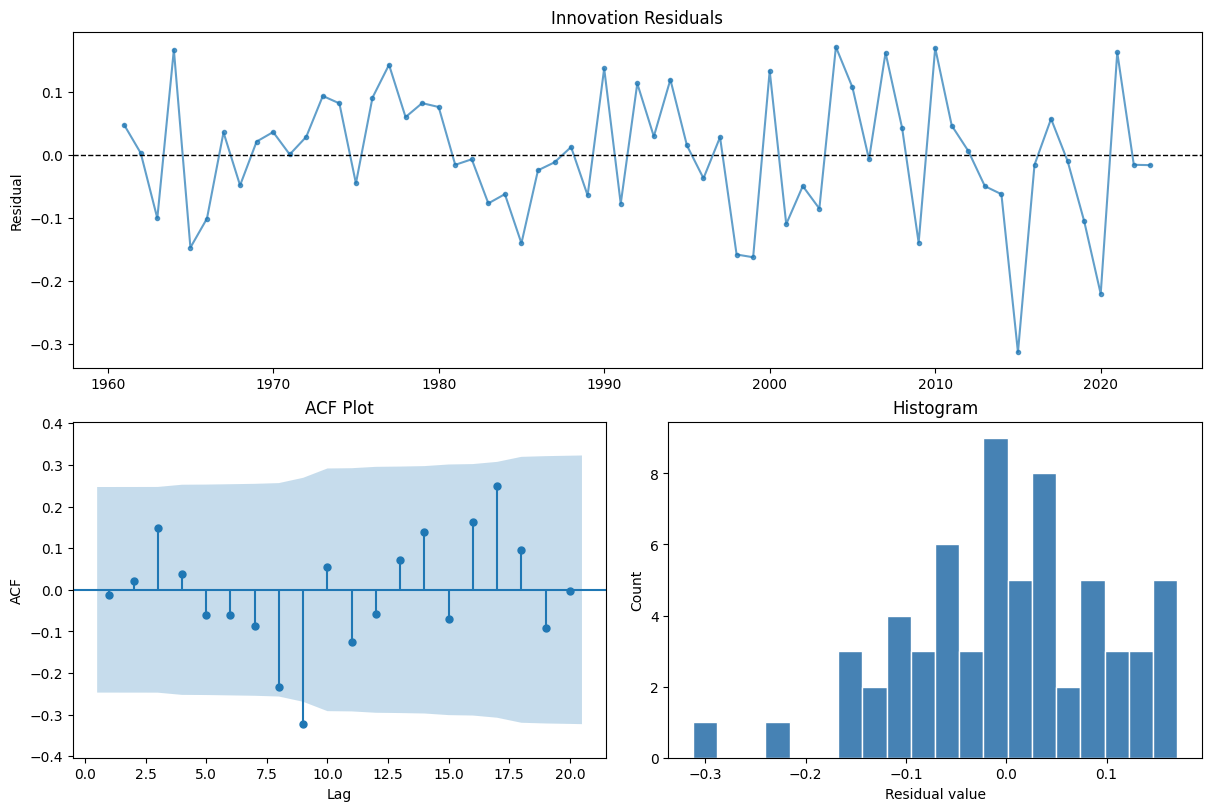

PRUEBA DE LJUNG-BOX Y DURBIN-WATSON
                    Test  Estadístico  P-valor          Conclusión
           Durbin-Watson       2.0231      NaN Sin autocorrelación
Ljung-Box (hasta lag 20)      26.6033   0.0641 Sin autocorrelación


In [70]:
# Verificar ruido blanco
plot_diagnostics(modelo = mejor_modelo, n_lags=20)

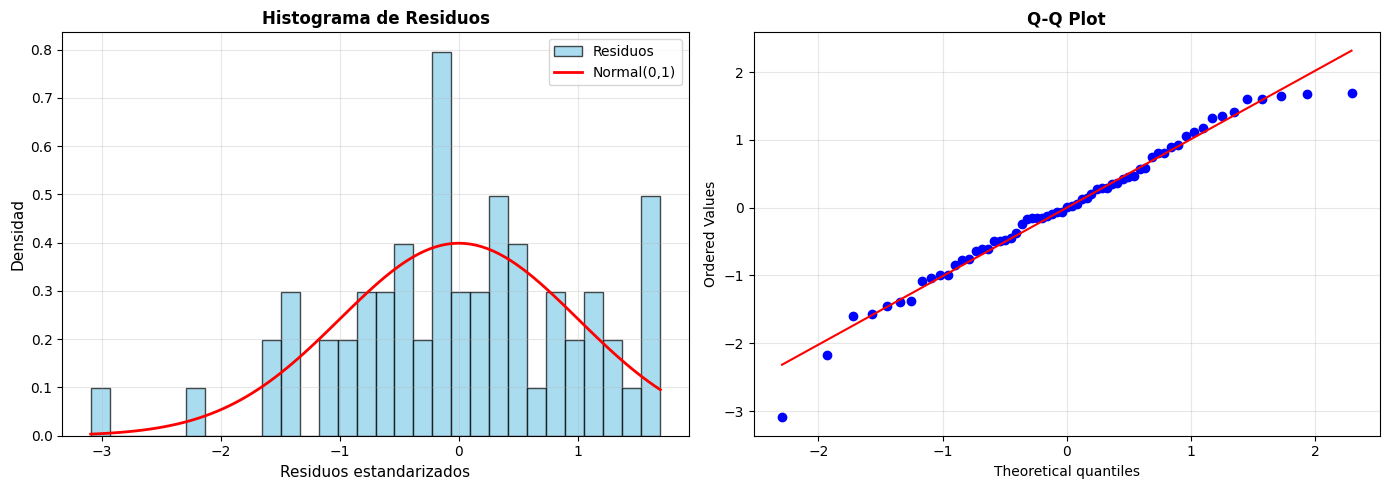

,test,estadistico,p_valor
0,Shapiro-Wilk,0.9771,0.2869
1,Jarque-Bera,1.9797,0.3716
2,Kolmogorov-Smirnov,0.0709,0.8873
3,Asimetría,-0.4128,NaN
4,Curtosis,3.2695,NaN


In [72]:
# Normalidad de los residuos
def check_normalidad(modelo):    
    # Verificación del tipo de modelo
    if 'statsmodels' not in str(type(modelo)):
        raise TypeError("El objeto debe ser un modelo ajustado de statsmodels.")
    
    # Extraer residuos estandarizados
    resid = modelo.resid
    resid_std = (resid - resid.mean()) / resid.std()
    
    # Gráfico 1: Histograma con curva normal
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax1 = axes[0]
    ax1.hist(resid_std, bins=30, density=True, alpha=0.7, 
             color='skyblue', edgecolor='black', label='Residuos')
    
    # Superponer curva normal teórica
    x = np.linspace(resid_std.min(), resid_std.max(), 100)
    ax1.plot(x, stats.norm.pdf(x, 0, 1), 'r-', linewidth=2, 
             label='Normal(0,1)')
    
    ax1.set_xlabel('Residuos estandarizados', fontsize=11)
    ax1.set_ylabel('Densidad', fontsize=11)
    ax1.set_title('Histograma de Residuos', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Gráfico 2: Q-Q Plot
    ax2 = axes[1]
    stats.probplot(resid_std, dist="norm", plot=ax2)
    ax2.set_title('Q-Q Plot', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Prueba de Shapiro-Wilk
    shapiro_stat, shapiro_p = stats.shapiro(resid)
    
    # Prueba de Jarque-Bera
    jb_stat, jb_p, skew, kurtosis = jarque_bera(resid)
    
    # Prueba de Kolmogorov-Smirnov
    ks_stat, ks_p = stats.kstest(resid_std, 'norm')
    
    # Resultados
    results = {
        'test' : ['Shapiro-Wilk', 'Jarque-Bera', 'Kolmogorov-Smirnov', 'Asimetría', 'Curtosis'],
        'estadistico' : [shapiro_stat, jb_stat, ks_stat, skew, kurtosis],
        'p_valor' : [shapiro_p, jb_p, ks_p, None, None]
    }
    tab_test = pd.DataFrame(results)
    tab_test[["estadistico", "p_valor"]] = tab_test[["estadistico", "p_valor"]].apply(lambda x: round(x, 4))
    return tab_test
    

check_normalidad(modelo = mejor_modelo)

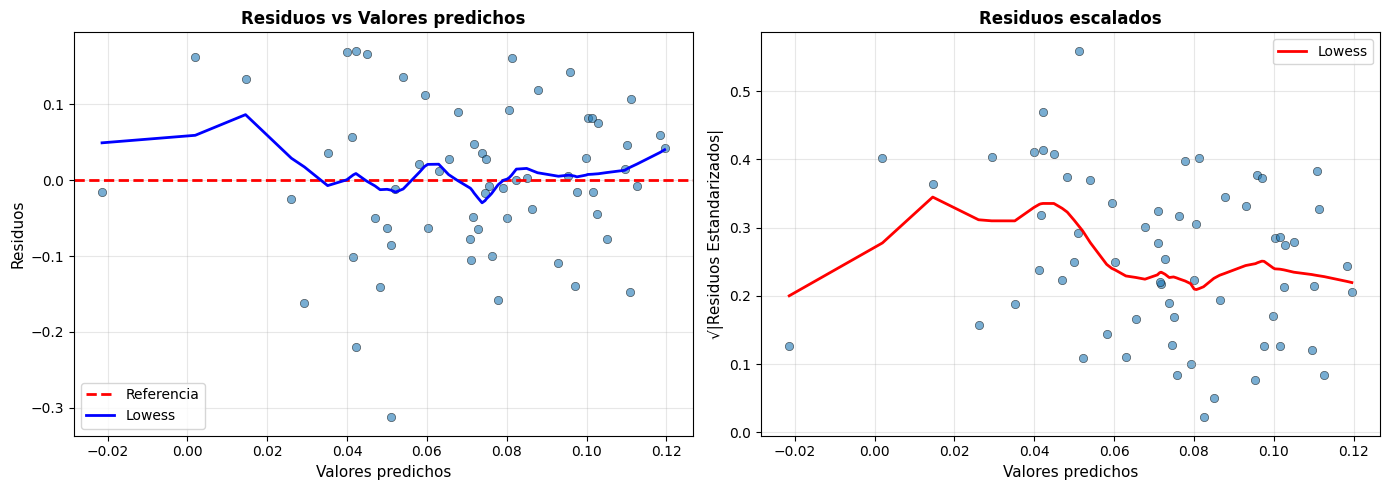

In [74]:
def check_homocedasticidad(modelo):
    # Verificación del tipo de modelo
    if 'statsmodels' not in str(type(modelo)):
        raise TypeError("El objeto debe ser un modelo ajustado de statsmodels.")
    
    # Extraer residuos y valores predichos del modelo
    resid = modelo.resid
    fitted_values = modelo.fittedvalues
    resid_abs = np.abs(resid)
    resid_sqrt = np.sqrt(resid_abs)
    
    # Crear figuras
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: Residuos vs Valores ajustados
    ax1 = axes[0]
    ax1.scatter(fitted_values, resid, alpha=0.6, edgecolors='k', linewidth=0.5)
    ax1.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Referencia')
    
    # Línea de tendencia
    smoothed = lowess(resid, fitted_values, frac=0.3)
    ax1.plot(smoothed[:, 0], smoothed[:, 1], color='blue', linewidth=2, label='Lowess')
    
    ax1.set_xlabel('Valores predichos', fontsize=11)
    ax1.set_ylabel('Residuos', fontsize=11)
    ax1.set_title('Residuos vs Valores predichos', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Gráfico 2: Residuos Estandarizados
    ax2 = axes[1]
    ax2.scatter(fitted_values, resid_sqrt, alpha=0.6, edgecolors='k', linewidth=0.5)
    
    # Línea de tendencia
    smoothed2 = lowess(resid_sqrt, fitted_values, frac=0.3)
    ax2.plot(smoothed2[:, 0], smoothed2[:, 1], color='red', linewidth=2, label='Lowess')
    
    ax2.set_xlabel('Valores predichos', fontsize=11)
    ax2.set_ylabel('√|Residuos Estandarizados|', fontsize=11)
    ax2.set_title('Residuos escalados', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

check_homocedasticidad(modelo=mejor_modelo)

## Pronóstico mejor modelo modelo crecimiento PIB

c:\Users\fsalcedo\AppData\Local\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\fsalcedo\AppData\Local\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


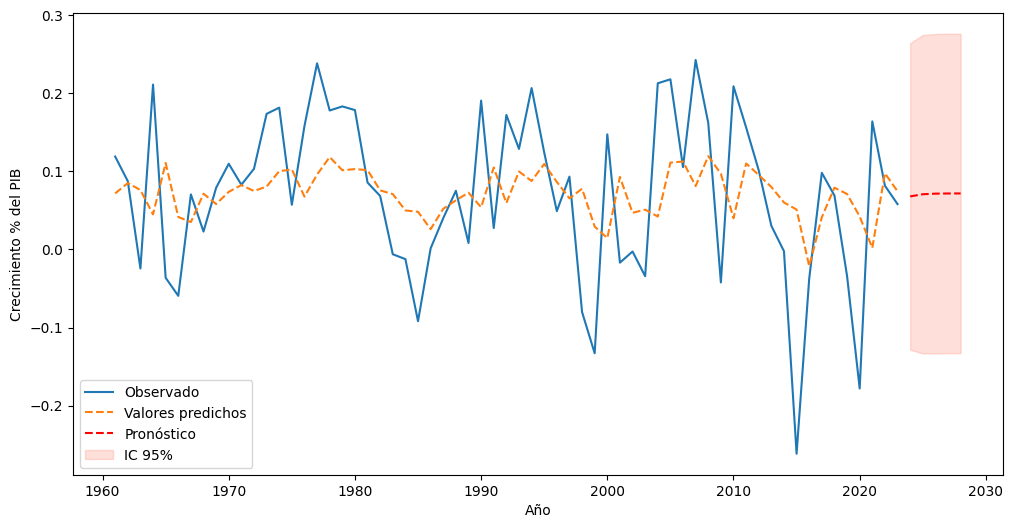

      Pronóstico  IC Inferior  IC Superior
Año                                       
2024    0.067946    -0.128430     0.264322
2025    0.070711    -0.133192     0.274613
2026    0.071483    -0.132996     0.275962
2027    0.071699    -0.132825     0.276223
2028    0.071760    -0.132768     0.276287


In [75]:
# Pronostico de los proximos 5 años
t_pronostico = 5
ultimo_anio  = data.index[-1]
anio_pronostico = range(ultimo_anio + 1, ultimo_anio + 1 + t_pronostico)

# Obtener valores promedios e intervalos del pronostico
pronostico_pib = mejor_modelo.get_forecast(steps=t_pronostico)
pred_mean = pronostico_pib.predicted_mean
pred_ci = pronostico_pib.conf_int()

# Alinear índice con la serie original
pred_mean.index = anio_pronostico
pred_ci.index   = anio_pronostico

# Graficar resultados pronostico
plt.figure(figsize=(12, 6))
ax = pib_crecimiento.plot(label = "Observado")
plt.plot(mejor_modelo.fittedvalues, label = "Valores predichos", linestyle = "--")
pred_mean.plot(ax = ax, label = "Pronóstico", linestyle = "--", color = "red")
ax.fill_between(
    pred_ci.index,
    pred_ci.iloc[:, 0],
    pred_ci.iloc[:, 1],
    color='tomato', alpha=.2, label="IC 95%"
)
ax.set_xlabel('Año')
ax.set_ylabel('Crecimiento % del PIB')
ax.legend()
plt.show()

# Tabla de pronóstico en niveles
df_forecast = pd.DataFrame({
    "Pronóstico" : pred_mean,
    "IC Inferior" : pred_ci.iloc[:, 0],
    "IC Superior" : pred_ci.iloc[:, 1]
})
df_forecast.index.name = "Año"
print(df_forecast.to_string())

## Pronostico en sus niveles del PIB

- Reversar la transformación logarítmico del crecimiento
$$
\Delta \log(PIB_t) = \log(PIB_t) - \log(PIB_{t-1})  \\
PIB_t = PIB_{t-1} * \exp^{\Delta \log(PIB_t)}
$$


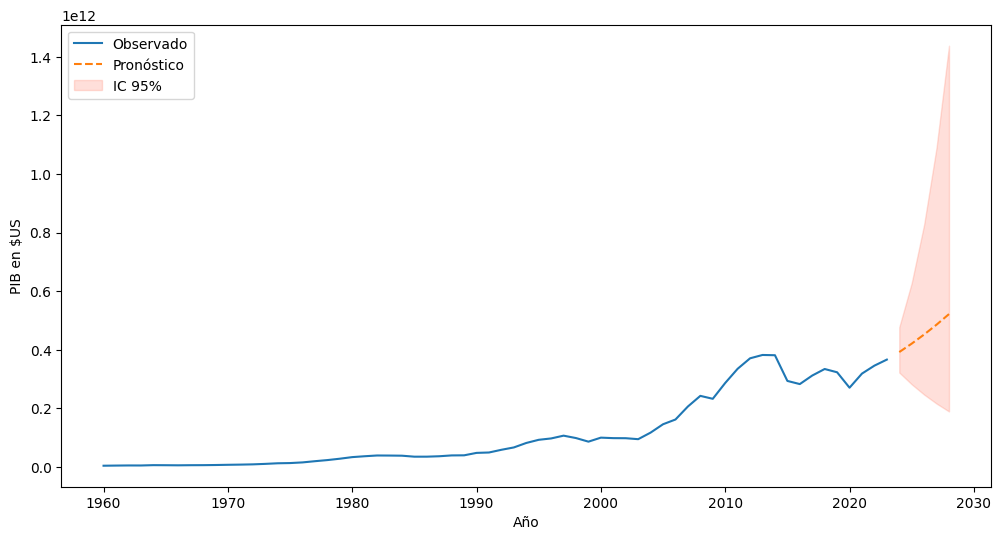

        Pronóstico   IC Inferior   IC Superior
Año                                           
2024  3.920448e+11  3.221444e+11  4.771126e+11
2025  4.207702e+11  2.819720e+11  6.278905e+11
2026  4.519493e+11  2.468577e+11  8.274331e+11
2027  4.855438e+11  2.161531e+11  1.090675e+12
2028  5.216668e+11  1.892785e+11  1.437756e+12


In [66]:
# Revertir log-diferencia a niveles
ultimo_pib_nivel = data["pib"].iloc[-1]

pred_niveles     = ultimo_pib_nivel * np.exp(pred_mean.cumsum())
pred_ci_niveles  = pd.DataFrame({
    "lower": ultimo_pib_nivel * np.exp(pred_ci.iloc[:, 0].cumsum()),
    "upper": ultimo_pib_nivel * np.exp(pred_ci.iloc[:, 1].cumsum())
}, index=pred_mean.index)

# Graficar resultados pronostico
plt.figure(figsize=(12, 6))
ax = data.pib.plot(label = "Observado")
pred_niveles.plot(ax = ax, label = "Pronóstico", linestyle = "--")
ax.fill_between(
    pred_ci_niveles.index,
    pred_ci_niveles["lower"],
    pred_ci_niveles["upper"],
    color="tomato", alpha=0.2, label="IC 95%"
)
ax.set_xlabel('Año')
ax.set_ylabel('PIB en $US')
ax.legend()
plt.show()

# Tabla de pronóstico en niveles
df_forecast = pd.DataFrame({
    "Pronóstico" : pred_niveles,
    "IC Inferior" : pred_ci_niveles["lower"],
    "IC Superior" : pred_ci_niveles["upper"],
})
df_forecast.index.name = "Año"
print(df_forecast.to_string())